# Preprint 3 — Multi-Step Kinetic Discovery for Fe₂O₃ Reduction
## Coupled Inverse PINN + SINDy for Three-Step Reaction Network

**Governing equations:**
  dX₁/dt = A₁·exp(-Ea₁/RT) · f₁(X₁)    Fe₂O₃ → Fe₃O₄  (JMA nucleation)
  dX₂/dt = A₂·exp(-Ea₂/RT) · f₂(X₂)    Fe₃O₄ → FeO     (JMA nucleation)
  dX₃/dt = A₃·exp(-Ea₃/RT) · f₃(X₃)    FeO   → Fe      (diffusion/zero-order)

**Weighted aggregation:**
  X_total = w₁·X₁ + w₂·X₂ + w₃·X₃
  Stoichiometric weights (mass of oxygen removed per step):
    w₁ = 0.111  (1/9 of total reducible oxygen)
    w₂ = 0.334  (3/9 of total reducible oxygen)
    w₃ = 0.555  (5/9 of total reducible oxygen)

**Algorithm:** Same coupled iterative loop as Preprint 2
  Step A: Inverse PINN → identify A_i, Ea_i (fixed f_i from previous iteration)
  Step B: SINDy      → discover f_i(X_i) (fixed A_i, Ea_i from Step A)
  Repeat until ΔA_i < 1%, ΔEa_i < 1%

**Key difference from Preprint 2:** Three separate pipelines run in parallel,
one per step, using Wang 2023 deconvoluted DTG data per step.

In [1]:
! pip install pysindy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 3.4 MB/s eta 0:00:00


Libraries

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps
from scipy.integrate import cumulative_trapezoid, solve_ivp
from scipy.signal import savgol_filter
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

 Mount Drive and load converted data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Scientific Machine Learning/PINN/My_Own_examples/Preprint_Folder/Colab Files/'

# Load the pre-converted data (from Notebook 1)
df_all = pd.read_csv(BASE + 'converted_data.csv')

# Physical constants
R     = 8.314
T_ref = 1000.0

# Stoichiometric weights (from Fe₂O₃→Fe mass balance)
WEIGHTS = {'Step_1_rxn': 0.111, 'Step_2_rxn': 0.334, 'Step_3_rxn': 0.555}

# Training and validation temperatures
TRAIN_T = [1023.15, 1123.15, 1173.15]   # 750, 850, 900°C
VALID_T  = [1073.15, 1223.15]             # 800, 950°C

TRAIN_T_PER_STEP = {
    'Step_1_rxn': [1023.15, 1123.15, 1173.15],
    'Step_2_rxn': [1023.15, 1123.15, 1173.15],
    'Step_3_rxn': [1023.15, 1073.15, 1123.15, 1173.15, 1223.15],
}

# Step labels for printing
STEP_LABELS = {
    'Step_1_rxn': 'Fe₂O₃→Fe₃O₄',
    'Step_2_rxn': 'Fe₃O₄→FeO',
    'Step_3_rxn': 'FeO→Fe'
}

print("Data loaded successfully.")
print("Steps:", df_all['Step'].unique())
print("Temperatures (K):", sorted(df_all['Temperature_K'].unique()))
print("Total rows:", len(df_all))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully.
Steps: ['Step_1_rxn' 'Step_2_rxn' 'Step_3_rxn']
Temperatures (K): [np.float64(1023.15), np.float64(1073.15), np.float64(1123.15), np.float64(1173.15), np.float64(1223.15)]
Total rows: 1018


Data preparation per step

In [4]:
def prepare_step_data(step_name):
    """
    Prepare training tensors for one reaction step.
    Returns dict with tensors for inverse PINN training.
    """
    df_s = df_all[df_all['Step'] == step_name].copy()
    result = {}

    for T_K in TRAIN_T + VALID_T:
        df_T = df_s[
            np.isclose(df_s['Temperature_K'], T_K, atol=0.5)
        ].dropna(subset=['X_active']).reset_index(drop=True)

        if len(df_T) == 0:
            continue

        t_phys = df_T['Time_s'].values
        X_obs  = df_T['X_active'].values
        t_end  = t_phys.max()

        # Normalise time and temperature
        t_norm = t_phys / t_end
        T_norm = T_K / T_ref

        result[T_K] = {
            't_phys':  t_phys,
            't_norm':  t_norm,
            'T_norm':  T_norm,
            'X_obs':   X_obs,
            't_end':   t_end,
            'n_pts':   len(df_T)
        }

    return result


# Prepare data for all three steps
step_data = {step: prepare_step_data(step) for step in WEIGHTS.keys()}

# Print summary
for step in WEIGHTS.keys():
    print(f"\n{STEP_LABELS[step]}:")
    for T_K, d in step_data[step].items():
        status = 'TRAIN' if T_K in TRAIN_T else 'VALID'
        print(f"  [{status}] T={T_K-273.15:.0f}°C: "
              f"n={d['n_pts']}, t_end={d['t_end']:.2f}s, "
              f"X=[{d['X_obs'].min():.3f},{d['X_obs'].max():.3f}]")


Fe₂O₃→Fe₃O₄:
  [TRAIN] T=750°C: n=68, t_end=52.80s, X=[0.032,0.968]
  [TRAIN] T=850°C: n=35, t_end=32.40s, X=[0.030,0.967]
  [TRAIN] T=900°C: n=46, t_end=37.80s, X=[0.033,0.970]
  [VALID] T=800°C: n=62, t_end=46.20s, X=[0.033,0.967]
  [VALID] T=950°C: n=83, t_end=54.60s, X=[0.030,0.970]

Fe₃O₄→FeO:
  [TRAIN] T=750°C: n=27, t_end=115.20s, X=[0.038,0.956]
  [TRAIN] T=850°C: n=37, t_end=120.00s, X=[0.031,0.960]
  [TRAIN] T=900°C: n=25, t_end=93.00s, X=[0.036,0.965]
  [VALID] T=800°C: n=34, t_end=126.00s, X=[0.035,0.966]
  [VALID] T=950°C: n=65, t_end=165.60s, X=[0.033,0.968]

FeO→Fe:
  [TRAIN] T=750°C: n=74, t_end=546.00s, X=[0.040,0.970]
  [TRAIN] T=850°C: n=70, t_end=498.00s, X=[0.036,0.969]
  [TRAIN] T=900°C: n=63, t_end=444.00s, X=[0.030,0.968]
  [VALID] T=800°C: n=78, t_end=552.00s, X=[0.034,0.970]
  [VALID] T=950°C: n=82, t_end=540.00s, X=[0.033,0.967]


PINN architecture (shared across all steps)

In [5]:
class StepPINN(nn.Module):
    """
    Main PINN for one reaction step.
    Input:  (t_norm, T_norm) — shape (N, 2)
    Output: X_i — step conversion ∈ [0, 1]
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return torch.sigmoid(self.net(x))   # X_i ∈ [0, 1]

SINDy libraries per step

In [6]:
def build_library_parameterised_JMA(n_discovered):
    """
    Single-term library using the discovered n from Step A.
    SINDy validates the coefficient — not discovering the form.
    Used for Steps 1 and 2 after n is learned.
    """
    n_safe = float(np.clip(n_discovered, 1.01, 5.0))
    exp    = (n_safe - 1.0) / n_safe

    return ps.CustomLibrary(
        library_functions=[
            lambda X: (1-X) * (-np.log(np.maximum(1-X, 1e-8)))**exp,
        ],
        function_names=[
            lambda x: f'(1-{x})(-ln(1-{x}))^{exp:.3f}'
        ]
    )


def build_library_steps_1_2_initial():
    """
    Initial library for Steps 1 and 2 — used in iteration 1
    before n is learned. Includes discrete JMA candidates.
    """
    return ps.CustomLibrary(
        library_functions=[
            lambda X: (1-X) * (-np.log(np.maximum(1-X, 1e-8)))**(0.5),
            lambda X: (1-X) * (-np.log(np.maximum(1-X, 1e-8)))**(2/3),
            lambda X: (1-X) * (-np.log(np.maximum(1-X, 1e-8)))**(3/4),
            lambda X: (-np.log(np.maximum(1-X, 1e-8)))**(0.5),
            lambda X: (-np.log(np.maximum(1-X, 1e-8)))**(2/3),
            lambda X: (1-X)**(2/3),
            lambda X: (1-X)**(1/3),
            lambda X: X * (1-X),
        ],
        function_names=[
            lambda x: f'(1-{x})(-ln(1-{x}))^0.5',
            lambda x: f'(1-{x})(-ln(1-{x}))^(2/3)',
            lambda x: f'(1-{x})(-ln(1-{x}))^(3/4)',
            lambda x: f'(-ln(1-{x}))^0.5',
            lambda x: f'(-ln(1-{x}))^(2/3)',
            lambda x: f'(1-{x})^(2/3)',
            lambda x: f'(1-{x})^(1/3)',
            lambda x: f'{x}(1-{x})',
        ]
    )


def build_library_step_3():
    """Step 3: flat-plateau type — diffusion or zero-order."""
    return ps.CustomLibrary(
        library_functions=[
            lambda X: np.ones_like(X),
            lambda X: 1.0 / (2.0 * np.maximum(X, 0.01)),
            lambda X: 1.0 - (2.0*X/3.0) - (1-X)**(2/3),
            lambda X: (1-X)**(2/3),
            lambda X: (1-X)**(1/3),
            lambda X: (1-X),
        ],
        function_names=[
            lambda x: '1',
            lambda x: f'1/(2{x})',
            lambda x: f'1-(2{x}/3)-(1-{x})^(2/3)',
            lambda x: f'(1-{x})^(2/3)',
            lambda x: f'(1-{x})^(1/3)',
            lambda x: f'(1-{x})',
        ]
    )


# Initial libraries — Step 1 and 2 will be updated after n is discovered
LIBRARIES = {
    'Step_1_rxn': build_library_steps_1_2_initial(),
    'Step_2_rxn': build_library_steps_1_2_initial(),
    'Step_3_rxn': build_library_step_3(),
}

print("SINDy libraries defined.")

SINDy libraries defined.


Step A: Inverse PINN for one step

In [7]:
def run_inverse_pinn_step(step_name, f_current,
                           log_k_init_dict, n_init,
                           n_epochs=10000):
    """
    Step A: Inverse PINN with independent rate constants.
    """
    USE_JMA = step_name in ['Step_1_rxn', 'Step_2_rxn']
    d = step_data[step_name]

    model  = StepPINN()
    log_k_vars = {T: torch.tensor(log_k_init_dict[T], dtype=torch.float32, requires_grad=True)
                  for T in TRAIN_T_PER_STEP[step_name] if T in d}
    n_exp  = torch.tensor(float(n_init), dtype=torch.float32,
                          requires_grad=USE_JMA)

    params = list(model.parameters()) + list(log_k_vars.values())
    if USE_JMA:
        params.append(n_exp)

    optimizer = torch.optim.Adam(params, lr=1e-3)

    gamma_per_step = {
        'Step_1_rxn': 0.99988,   # for 20k epochs → final LR ~1e-4
        'Step_2_rxn': 0.9998,    # for 10k epochs → final LR ~1.35e-4
        'Step_3_rxn': 0.99990,   # for 15k epochs → final LR ~2.2e-4
    }
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer, gamma=gamma_per_step[step_name]
    )

    # Build training tensors
    x_train_list, X_obs_list, t_max_list, T_K_list = [], [], [], []
    for T_K in TRAIN_T_PER_STEP[step_name]:
        if T_K not in d: continue
        dt = d[T_K]
        x_train_list.append(np.column_stack(
            [dt['t_norm'], np.full_like(dt['t_norm'], dt['T_norm'])]
        ))
        X_obs_list.append(dt['X_obs'].reshape(-1,1))
        t_max_list.extend([dt['t_end']] * len(dt['t_norm']))
        T_K_list.extend([T_K] * len(dt['t_norm']))

    x_train = torch.tensor(np.vstack(x_train_list), dtype=torch.float32)
    X_obs   = torch.tensor(np.vstack(X_obs_list),   dtype=torch.float32)
    t_max_t = torch.tensor(t_max_list, dtype=torch.float32).reshape(-1,1)

    # Collocation points
    coll_list, t_max_coll, T_K_coll = [], [], []
    for T_K in TRAIN_T_PER_STEP[step_name]:
        if T_K not in d: continue
        dt = d[T_K]
        t_c = np.linspace(0.01, 0.99, 80)
        coll_list.append(np.column_stack(
            [t_c, np.full_like(t_c, dt['T_norm'])]
        ))
        t_max_coll.extend([dt['t_end']] * 80)
        T_K_coll.extend([T_K] * 80)

    x_coll  = torch.tensor(np.vstack(coll_list), dtype=torch.float32)
    t_max_c = torch.tensor(t_max_coll, dtype=torch.float32).reshape(-1,1)

    # Map T_K back to k values for loss computation
    def get_k_tensor(T_K_array, log_k_vars_dict):
        k_vals = torch.zeros(len(T_K_array), 1)
        for i, t_val in enumerate(T_K_array):
            k_vals[i] = torch.exp(log_k_vars_dict[t_val])
        return k_vals

    T_ic  = torch.tensor(
        [[d[T]['T_norm']] for T in TRAIN_T_PER_STEP[step_name] if T in d], dtype=torch.float32
    )
    x_ic  = torch.cat([torch.zeros(len(T_ic), 1), T_ic], dim=1)

    def physics_f(X_coll):
        if USE_JMA:
            return f_JMA_param(X_coll, n_exp)
        else:
            return f_current(X_coll)

    with torch.no_grad():
        l_d0 = torch.mean((model(x_train) - X_obs)**2).item()

    x_c_req = x_coll.clone().requires_grad_(True)
    X_c = model(x_c_req)
    dXn = torch.autograd.grad(
        X_c, x_c_req,
        grad_outputs=torch.ones_like(X_c), create_graph=True
    )[0][:, 0:1]
    k_v  = get_k_tensor(T_K_coll, log_k_vars)
    l_p0 = torch.mean((dXn/t_max_c - k_v * physics_f(X_c))**2).item()

    lam = l_d0 / (l_p0 + 1e-12)
    print(f"  Epoch 0: data={l_d0:.4e}, phys={l_p0:.4e}, λ={lam:.0f}, "
          f"n={'learnable, init='+str(round(n_exp.item(),2)) if USE_JMA else 'fixed (Step 3)'}")

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        x_c_req = x_coll.clone().requires_grad_(True)
        X_c     = model(x_c_req)
        dXn     = torch.autograd.grad(
            X_c, x_c_req,
            grad_outputs=torch.ones_like(X_c), create_graph=True
        )[0][:, 0:1]
        k_vals = get_k_tensor(T_K_coll, log_k_vars)
        l_phys = torch.mean((dXn/t_max_c - k_vals * physics_f(X_c))**2)

        X_pred = model(x_train)
        l_data = torch.mean((X_pred - X_obs)**2)

        X_ic_pred = model(x_ic)
        l_ic = torch.mean(X_ic_pred**2)

        loss = lam * l_phys + l_data + 50.0 * l_ic
        loss.backward()
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            for k in log_k_vars:
                log_k_vars[k].clamp_(np.log(1e-6), np.log(10.0))
            if USE_JMA:
                n_exp.clamp_(1.01, 5.0)

        if epoch % 3000 == 0:
            n_val = f"{n_exp.item():.3f}" if USE_JMA else "N/A"
            print(f"  Epoch {epoch:5d} | Loss={loss.item():.4e} | n={n_val}")

    k_out = {T: torch.exp(log_k_vars[T]).item() for T in log_k_vars}
    return model, k_out, n_exp.item()


Step B: SINDy for one step

In [8]:
def run_sindy_step(step_name, pinn_model, k_dict,
                   n_discovered=None):
    """
    Step B: SINDy with individual rate constants.
    """
    USE_JMA = step_name in ['Step_1_rxn', 'Step_2_rxn']
    d = step_data[step_name]

    all_X, all_f = [], []

    for T_K in TRAIN_T_PER_STEP[step_name]:
        if T_K not in d or T_K not in k_dict: continue
        dt    = d[T_K]
        t_end = dt['t_end']

        t_uniform = torch.linspace(0.01, 0.99, 200).reshape(-1,1)
        T_col     = torch.full_like(t_uniform, dt['T_norm'])
        x_input   = torch.cat([t_uniform, T_col], dim=1).requires_grad_(True)

        X_pred     = pinn_model(x_input)
        dX_dt_norm = torch.autograd.grad(
            X_pred, x_input,
            grad_outputs=torch.ones_like(X_pred),
            create_graph=False
        )[0][:, 0:1]

        dX_dt_phys = (dX_dt_norm / t_end).detach().numpy().flatten()
        X_vals     = X_pred.detach().numpy().flatten()

        k_T = k_dict[T_K]
        f_vals = dX_dt_phys / (k_T + 1e-12)

        mask = (X_vals > 0.05) & (X_vals < 0.93) & (dX_dt_phys > 0)
        all_X.append(X_vals[mask])
        all_f.append(f_vals[mask])

    X_all = np.concatenate(all_X)
    f_all = np.concatenate(all_f)

    if USE_JMA:
        f0_scale = np.percentile(f_all, 90)
    else:
        f0_scale = np.percentile(f_all, 95)
    f_norm = np.clip(f_all / (f0_scale + 1e-8), 0.0, 3.0)

    if USE_JMA and n_discovered is not None:
        library = build_library_parameterised_JMA(n_discovered)
    else:
        library = LIBRARIES[step_name]

    best_model = None
    best_bic   = np.inf
    best_thresh = 0.1

    for thresh in [0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0, 5.0]:
        try:
            m = ps.SINDy(
                feature_library=library,
                optimizer=ps.STLSQ(threshold=thresh)
            )
            m.fit(X_all.reshape(-1,1),
                  t=np.arange(len(X_all)),
                  x_dot=f_norm.reshape(-1,1))

            coefs = m.coefficients()[0]
            n_nz  = max(np.sum(np.abs(coefs) > 1e-6), 1)

            f_pred = np.clip(
                np.asarray(m.predict(X_all.reshape(-1,1))).flatten(), 0, None
            )
            mse = np.mean((f_norm - f_pred)**2)
            bic = len(X_all)*np.log(mse+1e-12) + n_nz*np.log(len(X_all))

            coef_sum = np.sum(np.abs(coefs[np.abs(coefs) > 1e-6]))
            f_90     = np.percentile(np.abs(f_norm), 90)
            cancel   = coef_sum / (f_90 + 1e-8)
            phys_pen = max(0.0, np.log(cancel+1e-8) - np.log(3)) * 200

            X_check  = np.linspace(0.01, 0.99, 100).reshape(-1,1)
            f_check  = np.asarray(m.predict(X_check)).flatten()
            invalid  = 1000.0 if np.any(f_check < -0.1) else 0.0

            bic_mod  = bic + phys_pen + invalid

            if bic_mod < best_bic:
                best_bic = bic_mod; best_model = m; best_thresh = thresh

        except Exception as e:
            continue

    if best_model is None:
        best_model = m
        best_thresh = 5.0

    coefs = best_model.coefficients()[0]
    dom   = best_model.get_feature_names()[np.argmax(np.abs(coefs))]

    return best_model, X_all, f_norm, dom


f(X) callable from SINDy model

In [9]:
def f_initial_step1_step2(X):
    """Initial f(X) for Steps 1 and 2 — JMA n=2 as starting guess."""
    log_term = torch.clamp(-torch.log(torch.clamp(1-X, min=1e-6)), min=1e-6)
    return (1.0 - X) * torch.pow(log_term, 0.5)   # n=2: exponent=(2-1)/2=0.5

def f_initial_step3(X):
    """Initial f(X) for Step 3 — constant (zero-order as starting guess)."""
    return torch.ones_like(X)

F_INITIAL = {
    'Step_1_rxn': f_initial_step1_step2,
    'Step_2_rxn': f_initial_step1_step2,
    'Step_3_rxn': f_initial_step3,
}

def f_JMA_param(X, n):
    """
    Parameterised JMA model with learnable Avrami exponent n.
    f(X) = (1-X) * (-ln(1-X))^((n-1)/n)
    Physical range: n ∈ [1.01, 5.0]
    """
    n_safe   = torch.clamp(n, 1.01, 5.0)
    log_term = torch.clamp(-torch.log(torch.clamp(1-X, min=1e-6)), min=1e-6)
    exponent = (n_safe - 1.0) / n_safe
    return (1.0 - X) * torch.pow(log_term, exponent)

print("Initial f(X) functions and f_JMA_param defined.")

Initial f(X) functions and f_JMA_param defined.


Main coupled iterative loop (all three steps)

In [10]:
def f_from_sindy(sindy_model, X_tensor):
    X_np = X_tensor.detach().numpy().flatten()
    f_np = np.asarray(sindy_model.predict(X_np.reshape(-1,1))).flatten()
    f_np = np.clip(f_np, 0.0, 10.0)
    return torch.tensor(f_np, dtype=torch.float32).reshape(-1,1)

def run_coupled_pipeline_all_steps(
    max_iterations=10,
    tol=0.01
):
    init_params = {
        'Step_1_rxn': (np.log(7/60),  np.log(10300), 2.0),
        'Step_2_rxn': (np.log(19/60), np.log(26700), 2.0),
        'Step_3_rxn': (np.log(5/60),  np.log(24800), 2.0),
    }

    EPOCHS_PER_STEP = {
        'Step_1_rxn': 20000,
        'Step_2_rxn': 10000,
        'Step_3_rxn': 15000,
    }

    results = {}

    for step_name in WEIGHTS.keys():
        print(f"\n{'='*65}")
        print(f"STEP: {STEP_LABELS[step_name]}")
        print(f"{'='*65}")

        log_A_init, log_Ea_init, n_curr = init_params[step_name]

        # Initialize k_i for each temperature using the initial A and Ea
        log_k_curr = {}
        for T in TRAIN_T_PER_STEP[step_name]:
            log_k_curr[T] = log_A_init - (np.exp(log_Ea_init) / (R * T))

        f_curr    = F_INITIAL[step_name]
        sindy_mod = None
        USE_JMA   = step_name in ['Step_1_rxn', 'Step_2_rxn']

        history = {
            'A':    [np.exp(log_A_init)],
            'Ea':   [np.exp(log_Ea_init)/1000],
            'n':    [n_curr],
            'term': ['initial'],
        }

        for iteration in range(1, max_iterations + 1):
            print(f"\n  Iteration {iteration}")

            pinn_model, k_new, n_new = run_inverse_pinn_step(
                step_name, f_curr,
                log_k_curr, n_curr,
                EPOCHS_PER_STEP[step_name]
            )

            # Extract A and Ea via Arrhenius Plot (linear regression of ln(k) vs 1/T)
            T_arr = np.array(list(k_new.keys()))
            lnk_arr = np.log(np.array(list(k_new.values())))
            inv_T = 1.0 / T_arr

            slope, intercept = np.polyfit(inv_T, lnk_arr, 1)
            Ea_new = -slope * R
            A_new = np.exp(intercept)

            print(f"  Arrhenius Extracted: A={A_new:.4e}, Ea={Ea_new/1000:.2f} kJ/mol")

            sindy_mod, X_sindy, f_sindy, dom = run_sindy_step(
                step_name, pinn_model,
                k_new,
                n_discovered=n_new if USE_JMA else None
            )

            f_curr = lambda X, sm=sindy_mod: f_from_sindy(sm, X)

            A_prev, Ea_prev = history['A'][-1], history['Ea'][-1] * 1000
            delta_A  = abs(A_new - A_prev) / (A_prev + 1e-12)
            delta_Ea = abs(Ea_new - Ea_prev) / (Ea_prev + 1e-12)
            delta_n  = abs(n_new - n_curr) / (abs(n_curr) + 1e-6) if USE_JMA else 0.0

            history['A'].append(A_new)
            history['Ea'].append(Ea_new/1000)
            history['n'].append(n_new)
            history['term'].append(dom)

            # Update log_k_curr for next iteration (could be optional if PINN starts fresh, but good for tracking)
            for T in k_new:
                log_k_curr[T] = np.log(k_new[T])
            n_curr = n_new

            converged = delta_A < tol and delta_Ea < tol and (delta_n < tol or not USE_JMA)

            if converged:
                print(f"  ✅ CONVERGED at iteration {iteration}")
                break

        results[step_name] = {
            'A':        A_new,
            'Ea':       Ea_new / 1000,
            'n':        n_curr if USE_JMA else None,
            'log_A':    np.log(A_new),
            'log_Ea':   np.log(Ea_new),
            'pinn':     pinn_model,
            'sindy':    sindy_mod,
            'X_sindy':  X_sindy,
            'f_sindy':  f_sindy,
            'dom_term': dom,
            'history':  history,
            'weight':   WEIGHTS[step_name],
        }

    return results

print("Running decoupled PINN+SINDy (learnable n) for all three steps...")
results = run_coupled_pipeline_all_steps(
    max_iterations=50,
    tol=0.01
)


Running decoupled PINN+SINDy (learnable n) for all three steps...

STEP: Fe₂O₃→Fe₃O₄

  Iteration 1
  Epoch 0: data=1.2443e-01, phys=2.6032e-04, λ=478, n=learnable, init=2.0
  Epoch     0 | Loss=9.8297e+00 | n=2.001
  Epoch  3000 | Loss=5.6855e-03 | n=2.161
  Epoch  6000 | Loss=4.4316e-03 | n=2.371
  Epoch  9000 | Loss=2.6398e-03 | n=2.220
  Epoch 12000 | Loss=6.8525e-04 | n=2.155
  Epoch 15000 | Loss=5.1264e-04 | n=2.038
  Epoch 18000 | Loss=4.4408e-04 | n=1.948
  Arrhenius Extracted: A=5.3153e+00, Ea=34.22 kJ/mol

  Iteration 2
  Epoch 0: data=1.1451e-01, phys=3.2554e-03, λ=35, n=learnable, init=1.91
  Epoch     0 | Loss=1.2027e+01 | n=1.913
  Epoch  3000 | Loss=4.4948e-03 | n=2.280
  Epoch  6000 | Loss=4.1281e-03 | n=2.266
  Epoch  9000 | Loss=3.7539e-03 | n=2.109
  Epoch 12000 | Loss=3.6128e-04 | n=2.169
  Epoch 15000 | Loss=3.0150e-04 | n=2.099
  Epoch 18000 | Loss=2.6515e-04 | n=2.032
  Arrhenius Extracted: A=4.5127e+00, Ea=32.61 kJ/mol

  Iteration 3
  Epoch 0: data=1.0687e-01, 

Final results summary

In [11]:
print("=" * 70)
print("FINAL RESULTS — STEP-WISE KINETICS (learnable n)")
print("=" * 70)
print(f"{'Step':<20} {'A (s⁻¹)':>12} {'Ea (kJ/mol)':>12} "
      f"{'n':>6} {'f(X)':>32} {'w':>6}")
print("-" * 70)

for step, r in results.items():
    n_str = f"{r['n']:.3f}" if r['n'] is not None else "N/A"
    print(f"{STEP_LABELS[step]:<20} {r['A']:>12.4e} {r['Ea']:>12.2f} "
          f"{n_str:>6} {r['dom_term']:>32} {r['weight']:>6.3f}")

print("-" * 70)

print("\nComparison with Wang 2023:")
wang_ea = {'Step_1_rxn': 10.3, 'Step_2_rxn': 26.7, 'Step_3_rxn': 24.8}
wang_n  = {'Step_1_rxn': 2.0,  'Step_2_rxn': 2.0,  'Step_3_rxn': 3.0}
for step, r in results.items():
    d_ea = abs(r['Ea'] - wang_ea[step]) / wang_ea[step] * 100
    n_str = f"{r['n']:.3f}" if r['n'] else "N/A"
    w_n   = str(wang_n[step]) if step != 'Step_3_rxn' else 'JMA3'
    print(f"  {STEP_LABELS[step]}:")
    print(f"    Ea: {r['Ea']:.2f} vs {wang_ea[step]} kJ/mol (Δ={d_ea:.1f}%)")
    if r['n']:
        print(f"    n:  {r['n']:.3f} vs {w_n} (Wang 2023 assumed)")

FINAL RESULTS — STEP-WISE KINETICS (learnable n)
Step                      A (s⁻¹)  Ea (kJ/mol)      n                             f(X)      w
----------------------------------------------------------------------
Fe₂O₃→Fe₃O₄            4.5156e+00        32.60  2.008          (1-x0)(-ln(1-x0))^0.502  0.111
Fe₃O₄→FeO              4.6920e-01        23.49  2.008          (1-x0)(-ln(1-x0))^0.502  0.334
FeO→Fe                 1.4304e-02        12.01    N/A                     (1-x0)^(2/3)  0.555
----------------------------------------------------------------------

Comparison with Wang 2023:
  Fe₂O₃→Fe₃O₄:
    Ea: 32.60 vs 10.3 kJ/mol (Δ=216.5%)
    n:  2.008 vs 2.0 (Wang 2023 assumed)
  Fe₃O₄→FeO:
    Ea: 23.49 vs 26.7 kJ/mol (Δ=12.0%)
    n:  2.008 vs 2.0 (Wang 2023 assumed)
  FeO→Fe:
    Ea: 12.01 vs 24.8 kJ/mol (Δ=51.6%)


In [12]:
# Add this BEFORE the validation loop to check k values
print("Rate constants k_i(T) from discovered parameters:")
print(f"{'Step':<20} {'A (s⁻¹)':>12} {'Ea (kJ/mol)':>12} "
      f"{'k(750°C)':>12} {'k(900°C)':>12}")
for step, r in results.items():
    k_750 = r['A'] * np.exp(-r['Ea']*1000 / (R*1023.15))
    k_900 = r['A'] * np.exp(-r['Ea']*1000 / (R*1173.15))
    print(f"{STEP_LABELS[step]:<20} {r['A']:>12.4e} {r['Ea']:>12.2f} "
          f"{k_750:>12.6f} {k_900:>12.6f}")

Rate constants k_i(T) from discovered parameters:
Step                      A (s⁻¹)  Ea (kJ/mol)     k(750°C)     k(900°C)
Fe₂O₃→Fe₃O₄            4.5156e+00        32.60     0.097764     0.159591
Fe₃O₄→FeO              4.6920e-01        23.49     0.029665     0.042224
FeO→Fe                 1.4304e-02        12.01     0.003485     0.004175


Convergence plots per step

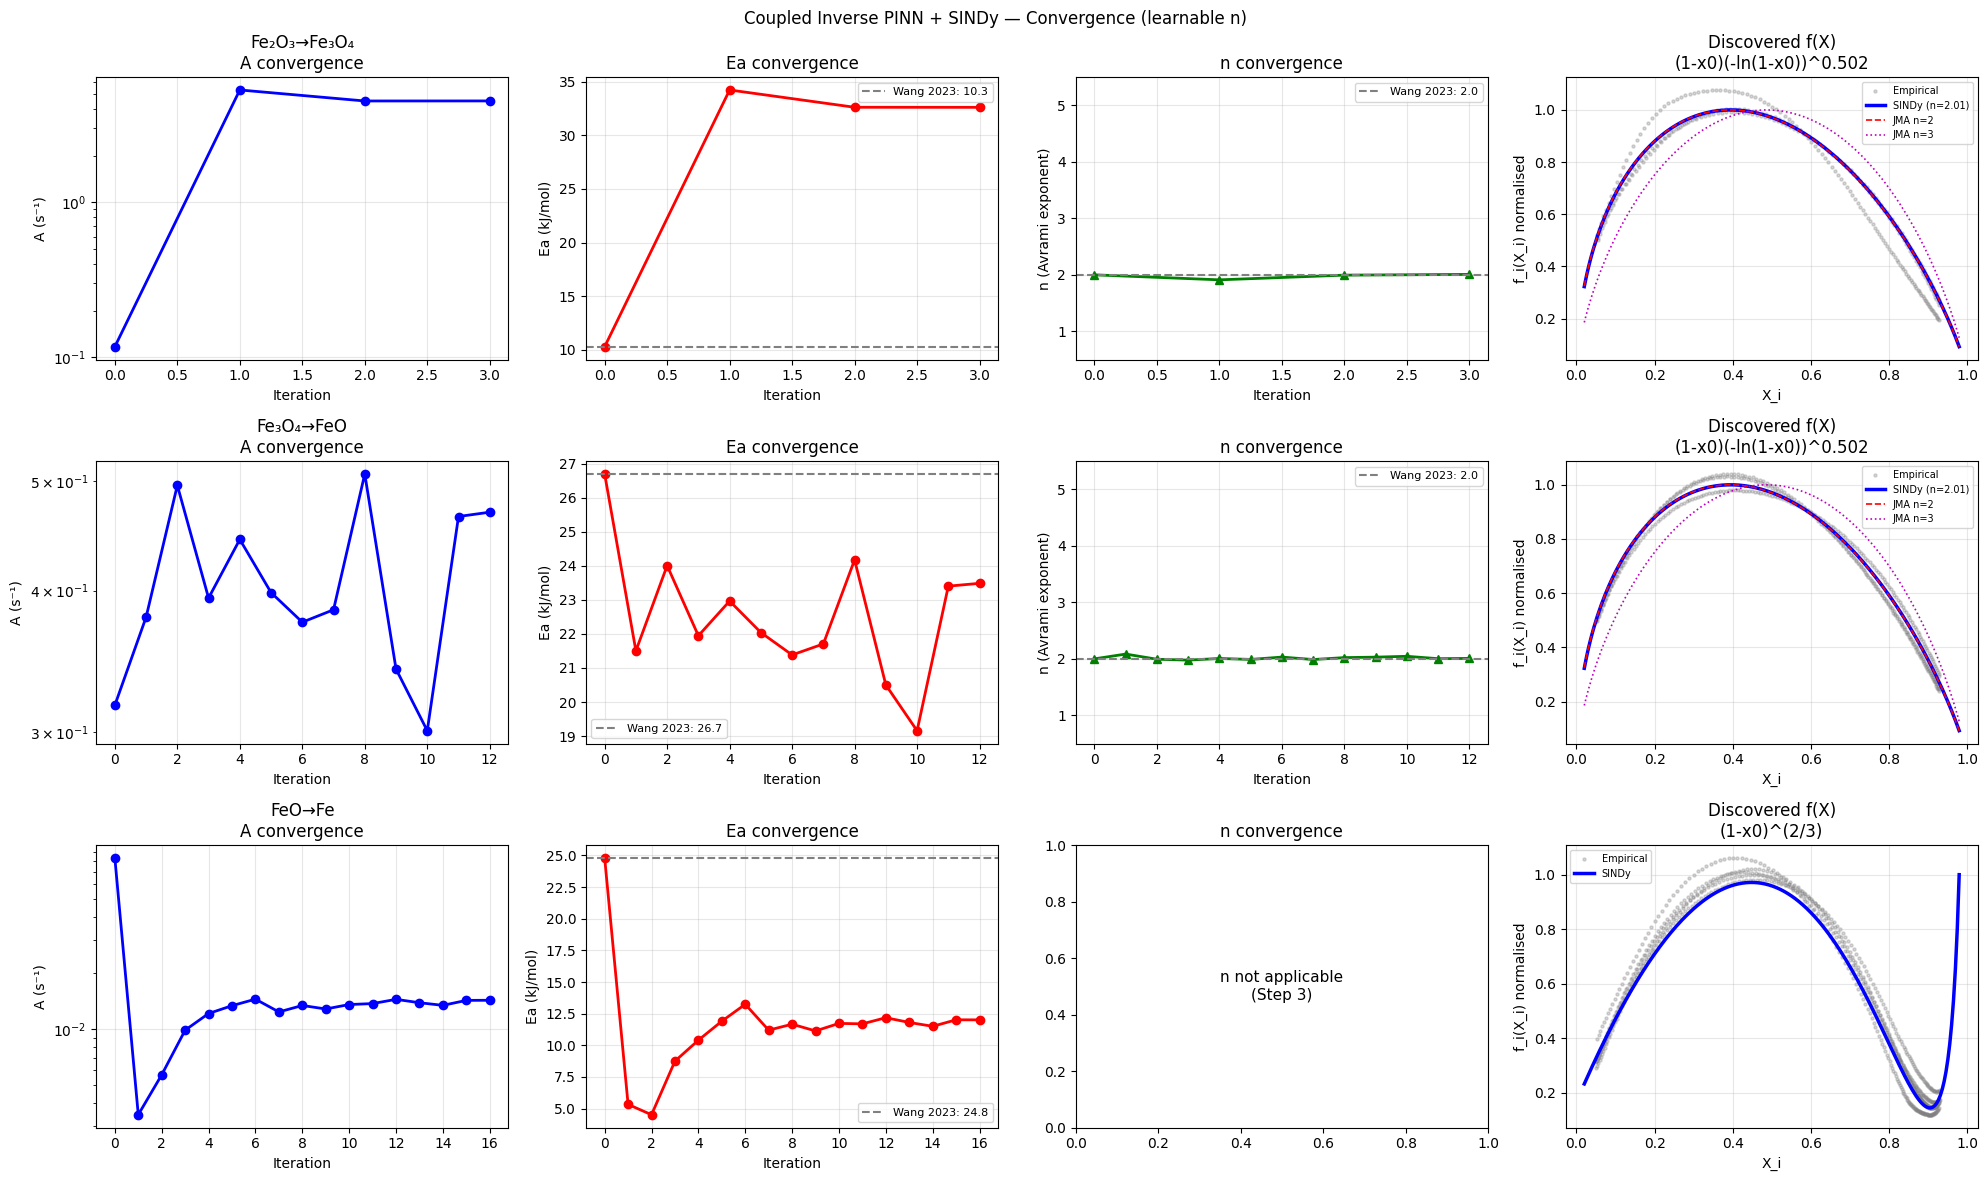

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
step_list = list(results.keys())

for si, step in enumerate(step_list):
    h    = results[step]['history']
    iters = list(range(len(h['A'])))
    USE_JMA = step in ['Step_1_rxn', 'Step_2_rxn']

    # A convergence
    axes[si, 0].semilogy(iters, h['A'], 'bo-', lw=2)
    axes[si, 0].set_xlabel('Iteration')
    axes[si, 0].set_ylabel('A (s⁻¹)')
    axes[si, 0].set_title(f"{STEP_LABELS[step]}\nA convergence")
    axes[si, 0].grid(True, alpha=0.3)

    # Ea convergence
    axes[si, 1].plot(iters, h['Ea'], 'ro-', lw=2)
    axes[si, 1].axhline(wang_ea[step], color='gray', ls='--',
                         label=f"Wang 2023: {wang_ea[step]}")
    axes[si, 1].set_xlabel('Iteration')
    axes[si, 1].set_ylabel('Ea (kJ/mol)')
    axes[si, 1].set_title('Ea convergence')
    axes[si, 1].legend(fontsize=8)
    axes[si, 1].grid(True, alpha=0.3)

    # n convergence (Steps 1 and 2 only)
    if USE_JMA:
        axes[si, 2].plot(iters, h['n'], 'g^-', lw=2)
        axes[si, 2].axhline(wang_n[step], color='gray', ls='--',
                             label=f"Wang 2023: {wang_n[step]}")
        axes[si, 2].set_xlabel('Iteration')
        axes[si, 2].set_ylabel('n (Avrami exponent)')
        axes[si, 2].set_title('n convergence')
        axes[si, 2].set_ylim(0.5, 5.5)
        axes[si, 2].legend(fontsize=8)
        axes[si, 2].grid(True, alpha=0.3)
    else:
        axes[si, 2].text(0.5, 0.5, 'n not applicable\n(Step 3)',
                          ha='center', va='center',
                          transform=axes[si,2].transAxes, fontsize=11)
        axes[si, 2].set_title('n convergence')

    # f(X) discovered
    r     = results[step]
    X_plt = np.linspace(0.02, 0.98, 200)
    with torch.no_grad():
        f_disc = f_from_sindy(
            r['sindy'],
            torch.tensor(X_plt, dtype=torch.float32)
        ).numpy().flatten()
    f_max = np.max(f_disc) + 1e-8

    axes[si, 3].scatter(r['X_sindy'], r['f_sindy'],
                         s=5, alpha=0.3, color='gray', label='Empirical')
    axes[si, 3].plot(X_plt, f_disc/f_max, 'b-', lw=2.5,
                     label=f'SINDy (n={r["n"]:.2f})' if r['n'] else 'SINDy')

    # Plot reference JMA curves for comparison
    if USE_JMA and r['n']:
        for n_ref, ls, lbl in [(2.0,'r--','JMA n=2'), (3.0,'m:','JMA n=3')]:
            X_t = torch.tensor(X_plt, dtype=torch.float32)
            n_t = torch.tensor(n_ref)
            f_r = f_JMA_param(X_t.reshape(-1,1),
                               n_t).detach().numpy().flatten()
            axes[si, 3].plot(X_plt, f_r/f_r.max(), ls, lw=1.2, label=lbl)

    axes[si, 3].set_xlabel('X_i')
    axes[si, 3].set_ylabel('f_i(X_i) normalised')
    axes[si, 3].set_title(f"Discovered f(X)\n{r['dom_term']}")
    axes[si, 3].legend(fontsize=7)
    axes[si, 3].grid(True, alpha=0.3)

wang_n = {'Step_1_rxn': 2.0, 'Step_2_rxn': 2.0, 'Step_3_rxn': 3.0}

plt.suptitle(
    'Coupled Inverse PINN + SINDy — Convergence (learnable n)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('multistep_convergence_learnable_n.png', dpi=130,
            bbox_inches='tight')
plt.show()

Forward validation per step

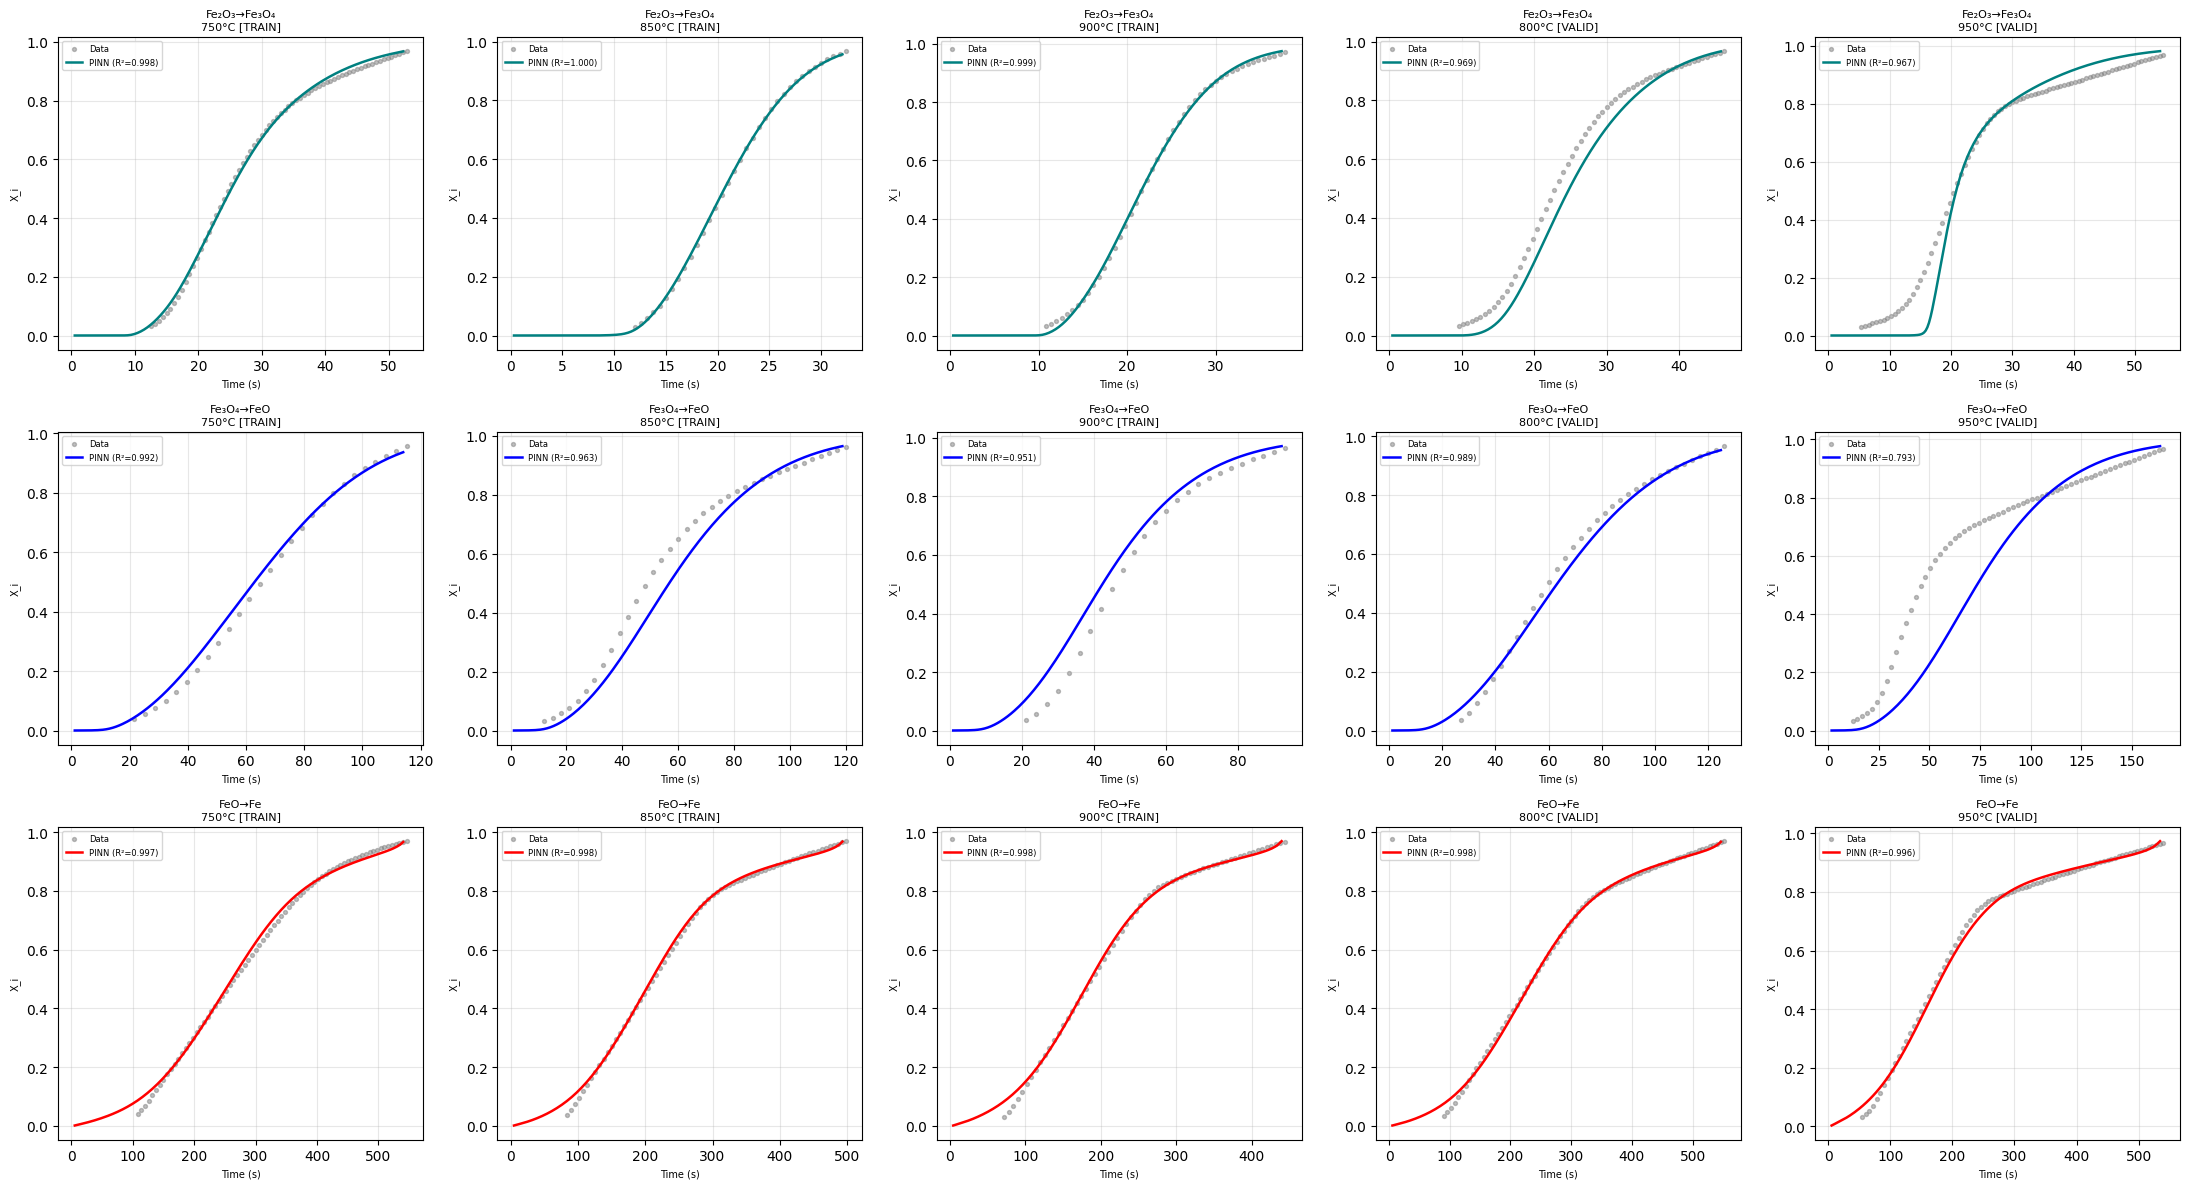

In [14]:
def validate_step(step_name, T_K, results):
    """Predict X_i(t) for one step at one temperature."""
    r = results[step_name]
    d = step_data[step_name]
    if T_K not in d:
        return None, None, None, None

    dt     = d[T_K]
    t_end  = dt['t_end']
    T_norm = dt['T_norm']

    t_plot = np.linspace(0.01, 0.99, 200)
    x_test = torch.tensor(
        np.column_stack([t_plot, np.full_like(t_plot, T_norm)]),
        dtype=torch.float32
    )

    r['pinn'].eval()
    with torch.no_grad():
        X_pred = r['pinn'](x_test).numpy().flatten()
    X_pred = np.clip(X_pred, 0, 1)

    t_phys = t_plot * t_end
    X_true = dt['X_obs']
    t_true = dt['t_norm'] * t_end

    r2 = r2_score(
        np.interp(t_true, t_phys, X_pred), X_true
    )
    return t_phys, X_pred, t_true, X_true, r2


fig, axes = plt.subplots(3, 5, figsize=(22, 12))
all_temps = TRAIN_T + VALID_T

for si, step in enumerate(step_list):
    for ti, T_K in enumerate(all_temps):
        res = validate_step(step, T_K, results)
        if res[0] is None:
            axes[si, ti].text(0.5, 0.5, 'No data',
                               ha='center', transform=axes[si,ti].transAxes)
            continue
        t_phys, X_pred, t_true, X_true, r2 = res
        status = 'TRAIN' if T_K in TRAIN_T else 'VALID'
        color  = ['teal','blue','red'][si]

        axes[si, ti].scatter(t_true, X_true, s=8, alpha=0.5,
                              color='gray', label='Data')
        axes[si, ti].plot(t_phys, X_pred, '-', color=color,
                           lw=1.8, label=f'PINN (R²={r2:.3f})')
        axes[si, ti].set_title(
            f"{STEP_LABELS[step]}\n{T_K-273.15:.0f}°C [{status}]",
            fontsize=8
        )
        axes[si, ti].set_xlabel('Time (s)', fontsize=7)
        axes[si, ti].set_ylabel('X_i', fontsize=7)
        axes[si, ti].legend(fontsize=6)
        axes[si, ti].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multistep_step_validation.png', dpi=130, bbox_inches='tight')
plt.show()

Weighted aggregation and overall X_total validation

AGGREGATED X_total vs Wang 2023 — Final Validation
   Temperature   R²_total   Status
-----------------------------------
  T=750°C: R²=0.9599 [TRAIN]
  T=850°C: R²=0.9824 [TRAIN]
  T=900°C: R²=0.9684 [TRAIN]
  T=800°C: R²=0.9796 [VALID]
  T=950°C: R²=0.9803 [VALID]


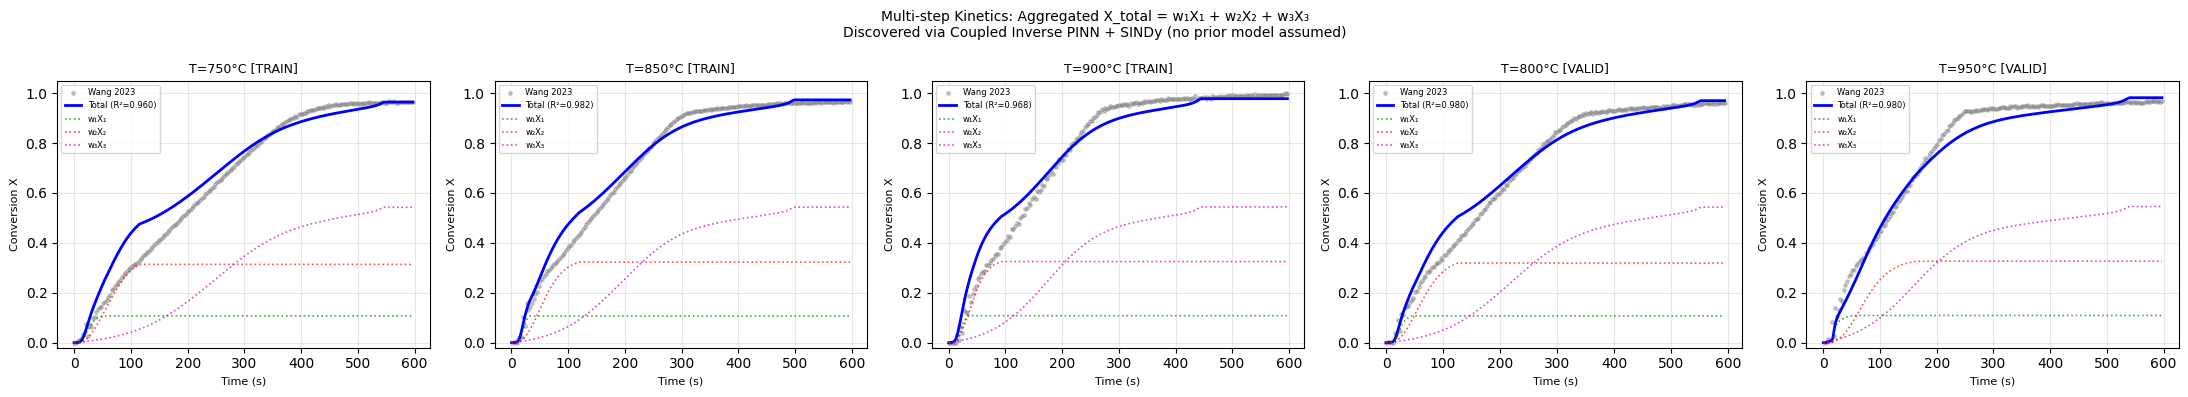

In [15]:
def aggregate_total_conversion(results, T_K):
    """
    Aggregate using PINN predictions directly on a shared global time axis.
    The PINNs were trained on `t_norm = Time_s / t_end` where Time_s
    is the global time, so no manual time-shifting (t_start) is needed.
    """
    df_T_total = df_total[
        np.isclose(df_total['Temperature (K)'], T_K, atol=0.5)
    ]
    if len(df_T_total) == 0:
        return None, None, None, None, None

    t_max_total = df_T_total['Time (s)'].max()
    t_global    = np.linspace(0, t_max_total, 500)

    steps = ['Step_1_rxn', 'Step_2_rxn', 'Step_3_rxn']
    X_step_global = {}

    for step in steps:
        r = results[step]
        d = step_data[step]

        if T_K not in d:
            X_step_global[step] = np.zeros_like(t_global)
            continue

        dt     = d[T_K]
        t_end  = dt['t_end']
        T_norm = dt['T_norm']

        # Time points on global axis, normalised by this step's t_end
        t_norm_global = np.clip(t_global / t_end, 0.0, 1.0)

        # Query PINN directly
        x_input = torch.tensor(
            np.column_stack([t_norm_global,
                             np.full_like(t_norm_global, T_norm)]),
            dtype=torch.float32
        )
        r['pinn'].eval()
        with torch.no_grad():
            X_pred = np.clip(
                r['pinn'](x_input).numpy().flatten(), 0, 1
            )

        X_step_global[step] = X_pred

    # Weighted aggregation
    w1 = WEIGHTS['Step_1_rxn']
    w2 = WEIGHTS['Step_2_rxn']
    w3 = WEIGHTS['Step_3_rxn']

    X_total = np.clip(
        w1 * X_step_global['Step_1_rxn'] +
        w2 * X_step_global['Step_2_rxn'] +
        w3 * X_step_global['Step_3_rxn'],
        0, 1
    )

    return (t_global, X_total,
            X_step_global['Step_1_rxn'],
            X_step_global['Step_2_rxn'],
            X_step_global['Step_3_rxn'])

# Load total Wang 2023 conversion data for comparison
df_total = pd.read_csv(BASE + 'combined_conversion_data_K_sec.csv')

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

print("=" * 65)
print("AGGREGATED X_total vs Wang 2023 — Final Validation")
print("=" * 65)
print(f"{'Temperature':>14} {'R²_total':>10} {'Status':>8}")
print("-" * 35)

for ti, T_K in enumerate(all_temps):
    result = aggregate_total_conversion(results, T_K)
    if result[0] is None:
        continue
    t_sim, X_total, X1, X2, X3 = result

    # Get Wang 2023 total data at this temperature
    df_T = df_total[
        np.isclose(df_total['Temperature (K)'], T_K, atol=0.5)
    ].copy()
    X0_raw = df_T['Conversion'].iloc[0]
    df_T['Conversion'] = ((df_T['Conversion'] - X0_raw) / (1 - X0_raw)).clip(0,1)
    t_wang = df_T['Time (s)'].values
    X_wang = df_T['Conversion'].values
    t_wang_m = t_wang[t_wang <= t_sim.max()]
    X_wang_m = X_wang[:len(t_wang_m)]

    # Interpolate simulation to Wang data time points
    X_pred_interp = np.interp(t_wang_m, t_sim, X_total)
    r2 = r2_score(X_wang_m, X_pred_interp)

    status = 'TRAIN' if T_K in TRAIN_T else 'VALID'
    print(f"  T={T_K-273.15:.0f}°C: R²={r2:.4f} [{status}]")

    ax = axes[ti]
    ax.scatter(t_wang_m, X_wang_m, s=6, alpha=0.4,
                color='gray', label='Wang 2023')
    ax.plot(t_sim, X_total, 'b-', lw=2, label=f'Total (R²={r2:.3f})')
    ax.plot(t_sim, X1*WEIGHTS['Step_1_rxn'], 'g:', lw=1.2,
             alpha=0.7, label=f'w₁X₁')
    ax.plot(t_sim, X2*WEIGHTS['Step_2_rxn'], 'r:', lw=1.2,
             alpha=0.7, label=f'w₂X₂')
    ax.plot(t_sim, X3*WEIGHTS['Step_3_rxn'], 'm:', lw=1.2,
             alpha=0.7, label=f'w₃X₃')
    ax.set_title(f"T={T_K-273.15:.0f}°C [{status}]", fontsize=9)
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('Conversion X', fontsize=8)
    ax.legend(fontsize=6)
    ax.set_ylim(-0.02, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Multi-step Kinetics: Aggregated X_total = w₁X₁ + w₂X₂ + w₃X₃\n'
    'Discovered via Coupled Inverse PINN + SINDy (no prior model assumed)',
    fontsize=10
)
plt.tight_layout()
plt.savefig('multistep_aggregated_validation.png', dpi=130, bbox_inches='tight')
plt.show()

Final comparison table for preprint

In [16]:
print("=" * 75)
print("FINAL COMPARISON TABLE — PREPRINT 3")
print("=" * 75)
print(f"{'Step':<20} {'This work Ea':>14} {'Wang 2023 Ea':>14} "
      f"{'This work f(X)':>25} {'Wang model':>12}")
print("-" * 75)

wang_models = {
    'Step_1_rxn': 'JMA (n≈2)',
    'Step_2_rxn': 'JMA (n≈2)',
    'Step_3_rxn': 'JMA (n≈3)'
}
for step, r in results.items():
    print(f"{STEP_LABELS[step]:<20} "
          f"{r['Ea']:>12.2f} kJ/mol "
          f"{wang_ea[step]:>12.1f} kJ/mol "
          f"{r['dom_term']:>25} "
          f"{wang_models[step]:>12}")

print("-" * 75)
print(f"\nWeighted aggregation:")
print(f"  X_total = {WEIGHTS['Step_1_rxn']}·X₁ + "
      f"{WEIGHTS['Step_2_rxn']}·X₂ + "
      f"{WEIGHTS['Step_3_rxn']}·X₃")
print(f"\nWeights from stoichiometry (mass fraction of O removed per step):")
print(f"  w₁=1/9={WEIGHTS['Step_1_rxn']:.3f}, "
      f"w₂=3/9={WEIGHTS['Step_2_rxn']:.3f}, "
      f"w₃=5/9={WEIGHTS['Step_3_rxn']:.3f}")

FINAL COMPARISON TABLE — PREPRINT 3
Step                   This work Ea   Wang 2023 Ea            This work f(X)   Wang model
---------------------------------------------------------------------------
Fe₂O₃→Fe₃O₄                 32.60 kJ/mol         10.3 kJ/mol   (1-x0)(-ln(1-x0))^0.502    JMA (n≈2)
Fe₃O₄→FeO                   23.49 kJ/mol         26.7 kJ/mol   (1-x0)(-ln(1-x0))^0.502    JMA (n≈2)
FeO→Fe                      12.01 kJ/mol         24.8 kJ/mol              (1-x0)^(2/3)    JMA (n≈3)
---------------------------------------------------------------------------

Weighted aggregation:
  X_total = 0.111·X₁ + 0.334·X₂ + 0.555·X₃

Weights from stoichiometry (mass fraction of O removed per step):
  w₁=1/9=0.111, w₂=3/9=0.334, w₃=5/9=0.555


In [17]:
print("k(T) comparison — This work vs Wang 2023")
print(f"{'Step':<20} {'T(°C)':>6} {'k_this (s⁻¹)':>14} {'k_Wang (s⁻¹)':>14} {'Ratio':>8}")
wang_params = {
    'Step_1_rxn': (0.117, 10300),
    'Step_2_rxn': (0.317, 26700),
    'Step_3_rxn': (0.083, 24800)
}
for step, r in results.items():
    A_w, Ea_w = wang_params[step]
    for T_K in TRAIN_T + VALID_T:
        k_this = r['A'] * np.exp(-r['Ea']*1000 / (R*T_K))
        k_wang = A_w * np.exp(-Ea_w / (R*T_K))
        ratio  = k_this / k_wang
        status = 'TRAIN' if T_K in TRAIN_T else 'VALID'
        print(f"{STEP_LABELS[step]:<20} {T_K-273.15:>6.0f} "
              f"{k_this:>14.6f} {k_wang:>14.6f} {ratio:>8.2f}x [{status}]")

k(T) comparison — This work vs Wang 2023
Step                  T(°C)   k_this (s⁻¹)   k_Wang (s⁻¹)    Ratio
Fe₂O₃→Fe₃O₄             750       0.097764       0.034860     2.80x [TRAIN]
Fe₂O₃→Fe₃O₄             850       0.137525       0.038828     3.54x [TRAIN]
Fe₂O₃→Fe₃O₄             900       0.159591       0.040697     3.92x [TRAIN]
Fe₂O₃→Fe₃O₄             800       0.116878       0.036883     3.17x [VALID]
Fe₂O₃→Fe₃O₄             950       0.182958       0.042492     4.31x [VALID]
Fe₃O₄→FeO               750       0.029665       0.013737     2.16x [TRAIN]
Fe₃O₄→FeO               850       0.037932       0.018166     2.09x [TRAIN]
Fe₃O₄→FeO               900       0.042224       0.020521     2.06x [TRAIN]
Fe₃O₄→FeO               800       0.033737       0.015901     2.12x [VALID]
Fe₃O₄→FeO               950       0.046592       0.022951     2.03x [VALID]
FeO→Fe                  750       0.003485       0.004497     0.77x [TRAIN]
FeO→Fe                  850       0.003952       0.00583

Using hardcoded results from previous training to avoid 3-hour wait.


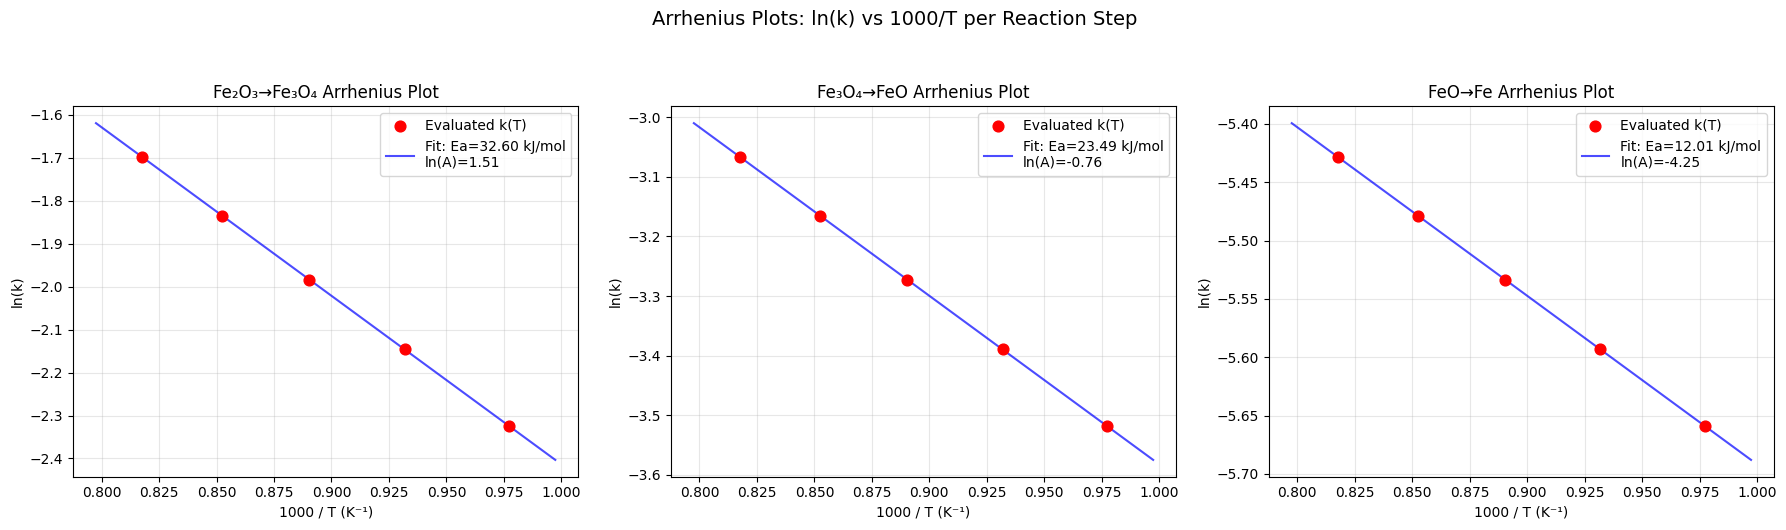

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Physical constants and labels (in case earlier cells weren't run)
R = 8.314
TRAIN_T = [1023.15, 1123.15, 1173.15]
VALID_T = [1073.15, 1223.15]
STEP_LABELS = {
    'Step_1_rxn': 'Fe₂O₃→Fe₃O₄',
    'Step_2_rxn': 'Fe₃O₄→FeO',
    'Step_3_rxn': 'FeO→Fe'
}

# Use the discovered values from your previous run to save time!
if 'results' not in globals() and 'results' not in locals():
    print("Using hardcoded results from previous training to avoid 3-hour wait.")
    results = {
        'Step_1_rxn': {'A': 4.5156e+00, 'Ea': 32.60},
        'Step_2_rxn': {'A': 4.6920e-01, 'Ea': 23.49},
        'Step_3_rxn': {'A': 1.4304e-02, 'Ea': 12.01}
    }

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
step_list = list(results.keys())
all_T = np.array(TRAIN_T + VALID_T)
inv_T = 1000.0 / all_T

for si, step in enumerate(step_list):
    r = results[step]
    A = r['A']
    Ea_J = r['Ea'] * 1000  # Convert kJ/mol to J/mol

    # Calculate ln(k) for all temperatures
    ln_k = np.log(A) - Ea_J / (R * all_T)

    ax = axes[si]
    # Scatter points for evaluated temperatures
    ax.scatter(inv_T, ln_k, color='red', s=60, label='Evaluated k(T)', zorder=5)

    # Continuous line for the Arrhenius fit
    inv_T_line = np.linspace(min(inv_T) - 0.02, max(inv_T) + 0.02, 100)
    T_line = 1000.0 / inv_T_line
    ln_k_line = np.log(A) - Ea_J / (R * T_line)

    ax.plot(inv_T_line, ln_k_line, 'b-', alpha=0.7,
            label=f'Fit: Ea={r["Ea"]:.2f} kJ/mol\nln(A)={np.log(A):.2f}')

    ax.set_title(f"{STEP_LABELS.get(step, step)} Arrhenius Plot")
    ax.set_xlabel('1000 / T (K⁻¹)')
    ax.set_ylabel('ln(k)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Arrhenius Plots: ln(k) vs 1000/T per Reaction Step', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

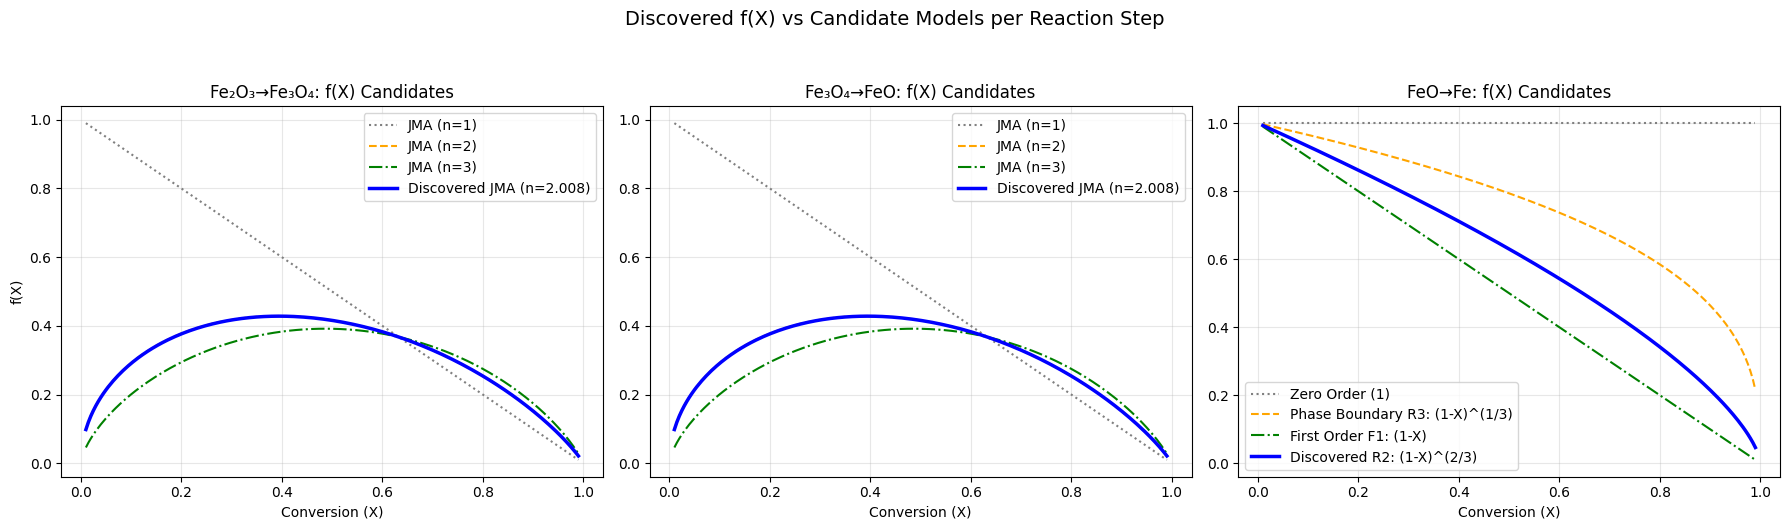

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
X_vals = np.linspace(0.01, 0.99, 200)

# Helper function for JMA models: f(X) = (1-X) * (-ln(1-X))^((n-1)/n)
def f_jma(X, n):
    return (1 - X) * (-np.log(1 - X))**((n - 1) / n)

# --- Step 1: Fe₂O₃ → Fe₃O₄ ---
ax = axes[0]
ax.plot(X_vals, f_jma(X_vals, 1.0), ':', label='JMA (n=1)', color='gray')
ax.plot(X_vals, f_jma(X_vals, 2.0), '--', label='JMA (n=2)', color='orange')
ax.plot(X_vals, f_jma(X_vals, 3.0), '-.', label='JMA (n=3)', color='green')
# Discovered n = 2.008
ax.plot(X_vals, f_jma(X_vals, 2.008), '-', label='Discovered JMA (n=2.008)', color='blue', linewidth=2.5)
ax.set_title('Fe₂O₃→Fe₃O₄: f(X) Candidates')
ax.set_xlabel('Conversion (X)')
ax.set_ylabel('f(X)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Step 2: Fe₃O₄ → FeO ---
ax = axes[1]
ax.plot(X_vals, f_jma(X_vals, 1.0), ':', label='JMA (n=1)', color='gray')
ax.plot(X_vals, f_jma(X_vals, 2.0), '--', label='JMA (n=2)', color='orange')
ax.plot(X_vals, f_jma(X_vals, 3.0), '-.', label='JMA (n=3)', color='green')
# Discovered n = 2.008
ax.plot(X_vals, f_jma(X_vals, 2.008), '-', label='Discovered JMA (n=2.008)', color='blue', linewidth=2.5)
ax.set_title('Fe₃O₄→FeO: f(X) Candidates')
ax.set_xlabel('Conversion (X)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Step 3: FeO → Fe ---
ax = axes[2]
ax.plot(X_vals, np.ones_like(X_vals), ':', label='Zero Order (1)', color='gray')
ax.plot(X_vals, (1 - X_vals)**(1/3), '--', label='Phase Boundary R3: (1-X)^(1/3)', color='orange')
ax.plot(X_vals, 1 - X_vals, '-.', label='First Order F1: (1-X)', color='green')
# Discovered term: R2 Contracting Area
ax.plot(X_vals, (1 - X_vals)**(2/3), '-', label='Discovered R2: (1-X)^(2/3)', color='blue', linewidth=2.5)
ax.set_title('FeO→Fe: f(X) Candidates')
ax.set_xlabel('Conversion (X)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Discovered f(X) vs Candidate Models per Reaction Step', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()